In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import timm, types, sys
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from peft import LoraConfig
from peft.tuners.lora import LoraModel
from sklearn.metrics import f1_score
import torchvision.transforms as T

sys.path.append(".")
from src.dataset import HistologicalImageDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [7]:
DATASET_NAME = "BREAKHIS"   

CFG = dict(
    data_dir        = f"/data/{DATASET_NAME}",
    img_size        = 224,
    batch_size      = 1,
    num_workers     = 1,
    seed            = 42,
    classifier_ckpt = Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}/uni_finetuned/best_model.pt"),
    forecaster_ckpt = Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}/forecaster/forecaster_src02_tgt23.pt"),
    finetuned_pruned_ckpt = Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}/pruned_finetuned/best_prune_layer2_keep10.pt"),
    results_dir     = Path(f"results/{DATASET_NAME}"),
    prune_layer     = 2,
    far_threshold   = 1e-4,
    keep_ratios     = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
)
torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
CFG["results_dir"].mkdir(parents=True, exist_ok=True)


In [8]:
eval_tf = T.Compose([
    T.Resize((CFG["img_size"], CFG["img_size"])),
    T.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])
test_ds     = HistologicalImageDataset(f"{CFG['data_dir']}/test", transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"],
                         shuffle=False, num_workers=CFG["num_workers"],
                         pin_memory=True, persistent_workers=True)
CLASS_NAMES = test_ds.class_names
N_CLASSES   = len(CLASS_NAMES)
print(f"Test samples: {len(test_ds)} | Classi: {CLASS_NAMES}")


Loading from /data/BREAKHIS/test...
Loaded 6833 samples, 8 classes
Class distribution:
  adenosis: 540 (7.9%)
  fibroadenoma: 693 (10.1%)
  phyllodes_tumor: 423 (6.2%)
  tubular_adenoma: 602 (8.8%)
  ductal_carcinoma: 2769 (40.5%)
  lobular_carcinoma: 602 (8.8%)
  mucinous_carcinoma: 757 (11.1%)
  papillary_carcinoma: 447 (6.5%)
Test samples: 6833 | Classi: ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma', 'ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']


In [9]:
def compute_tar_at_far(scores, is_correct, far_threshold=1e-4):
    scores    = np.array(scores)
    correct   = np.array(is_correct).astype(bool)
    incorrect = ~correct
    if incorrect.sum() == 0:
        return 1.0
    n_far     = max(1, int(np.ceil(incorrect.sum() * far_threshold)))
    threshold = np.sort(scores[incorrect])[::-1][min(n_far-1, incorrect.sum()-1)]
    return float((scores[correct] >= threshold).mean())


def compute_metrics(all_preds, all_labels, all_scores, far_threshold=1e-4):
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    f1         = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    is_correct = (all_preds == all_labels)
    tar        = compute_tar_at_far(all_scores, is_correct, far_threshold)
    return {"f1_macro": f1, "tar_at_far": tar}


In [10]:
class UNILoRAClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model("hf-hub:MahmoodLab/uni", pretrained=True,
                                      init_values=1e-5, dynamic_img_size=True)
        lora_config = LoraConfig(r=8, lora_alpha=32,
            target_modules=["qkv","proj","fc1","fc2"],
            lora_dropout=0.1, bias="none")
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes))
    def forward(self, x):
        return self.head(self.backbone(x))


class AttentionForecaster(nn.Module):
    def __init__(self, embed_dim=1024, hidden=256, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(embed_dim, hidden)
        self.cls_query   = nn.Parameter(torch.randn(1,1,hidden)*0.02)
        self.self_attn   = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=hidden, nhead=n_heads,
                dim_feedforward=hidden*2, dropout=dropout,
                batch_first=True, norm_first=True) for _ in range(n_layers)])
        self.cross_attn  = nn.ModuleList([
            nn.MultiheadAttention(hidden, n_heads, dropout=dropout, batch_first=True)
            for _ in range(n_layers)])
        self.cross_norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])
        self.norm        = nn.LayerNorm(hidden)
        self.score_head  = nn.Sequential(
            nn.Linear(hidden*2,128), nn.GELU(), nn.Dropout(dropout), nn.Linear(128,1))
    def forward(self, x):
        B, N, D = x.shape
        x = self.input_proj(x)
        for sa in self.self_attn: x = sa(x)
        cls = self.cls_query.expand(B,-1,-1)
        for ca, norm in zip(self.cross_attn, self.cross_norms):
            cls_out, _ = ca(cls, x, x); cls = norm(cls + cls_out)
        x_norm  = self.norm(x)
        cls_exp = cls.expand(-1,N,-1)
        return self.score_head(torch.cat([x_norm,cls_exp],dim=-1)).squeeze(-1).softmax(-1)


# # Carica classificatore fine-tuned
# classifier = UNILoRAClassifier(N_CLASSES).to(device)
# classifier.load_state_dict(
#     torch.load(CFG["classifier_ckpt"], map_location=device), strict=False)
# classifier.eval()
# for p in classifier.parameters(): p.requires_grad_(False)

# # Carica forecaster
# forecaster = AttentionForecaster().to(device)
# forecaster.load_state_dict(torch.load(CFG["forecaster_ckpt"], map_location=device))
# forecaster.eval()
# for p in forecaster.parameters(): p.requires_grad_(False)

# # Carica classificatore fine-tuned CON pruning
# classifier_ft_pruned = UNILoRAClassifier(N_CLASSES).to(device)
# classifier_ft_pruned.load_state_dict(
#     torch.load(CFG["finetuned_pruned_ckpt"], map_location=device), strict=False)
# classifier_ft_pruned.eval()
# for p in classifier_ft_pruned.parameters(): p.requires_grad_(False)

# print("Modelli caricati")

In [7]:
import matplotlib.gridspec as gridspec

N_IMAGES = 4
PRUNE_LAYER = CFG["prune_layer"]
TARGET_LAYER = 23


def collect_attention_maps(model, forecaster, imgs_dev, prune_layer, target_layer):
    """
    Raccoglie per ogni immagine:
    - CLS attention @ prune_layer
    - Importanza predetta dal forecaster
    - CLS attention @ target_layer
    """
    cache = {}
    orig = {}

    def make_hook(idx):
        def fwd(self, x):
            B, N, C = x.shape
            qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv.unbind(0)
            q, k = self.q_norm(q), self.k_norm(k)
            attn = (q @ k.transpose(-2, -1) * self.scale).softmax(-1)
            if idx == prune_layer:
                cache["emb_x"] = x[:, 1:].detach()
                cache["attn_x"] = attn[:, :, 0, 1:].mean(1).detach()
            if idx == target_layer:
                cache["attn_y"] = attn[:, :, 0, 1:].mean(1).detach()
            x = (self.attn_drop(attn) @ v).transpose(1, 2).reshape(B, N, C)
            return self.proj_drop(self.proj(x))

        return fwd

    for i, block in enumerate(model.backbone.model.blocks):
        orig[i] = block.attn.forward
        block.attn.forward = types.MethodType(make_hook(i), block.attn)

    with torch.no_grad():
        model(imgs_dev)
        pred_importance = forecaster(cache["emb_x"])

    for i, block in enumerate(model.backbone.model.blocks):
        block.attn.forward = orig[i]

    return cache["attn_x"].cpu(), pred_importance.cpu(), cache["attn_y"].cpu()


def select_representative_images(model, forecaster, loader, device, n_images, prune_layer, target_layer, max_scan_batches=30):
    """
    Seleziona immagini con alta coerenza tra mappa predetta dal forecaster
    e mappa CLS del layer target.
    """
    sims_all, imgs_all, labels_all = [], [], []

    scanned = 0
    for imgs, labels in loader:
        imgs_dev = imgs.to(device)
        _, attn_pred_b, attn_y_b = collect_attention_maps(
            model, forecaster, imgs_dev, prune_layer, target_layer
        )

        pred_n = torch.nn.functional.normalize(attn_pred_b.float(), p=2, dim=1)
        targ_n = torch.nn.functional.normalize(attn_y_b.float(), p=2, dim=1)
        sims = (pred_n * targ_n).sum(dim=1)

        sims_all.append(sims.cpu())
        imgs_all.append(imgs.cpu())
        labels_all.append(labels.cpu())

        scanned += 1
        if scanned >= max_scan_batches:
            break

    sims_all = torch.cat(sims_all)
    imgs_all = torch.cat(imgs_all)
    labels_all = torch.cat(labels_all)

    topk_idx = torch.topk(sims_all, k=min(n_images, len(sims_all)), largest=True).indices
    return imgs_all[topk_idx], labels_all[topk_idx]


sample_imgs, sample_labels = select_representative_images(
    classifier,
    forecaster,
    test_loader,
    device,
    N_IMAGES,
    PRUNE_LAYER,
    TARGET_LAYER,
    max_scan_batches=30,
)

attn_x, attn_pred, attn_y = collect_attention_maps(
    classifier, forecaster, sample_imgs.to(device), PRUNE_LAYER, TARGET_LAYER
)


def to_map(vec):
    m = vec.reshape(14, 14).numpy()
    m = (m - m.min()) / (m.max() - m.min() + 1e-8)
    return m


def unnorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.permute(1, 2, 0).clamp(0, 1).numpy()


CMAP = "magma"
ALPHA = 0.58
ROW_LABELS = [
    f"A) Layer {PRUNE_LAYER} attention",
    f"B) Forecaster prediction",
    f"C) Layer {TARGET_LAYER} attention",
]

fig = plt.figure(figsize=(3.2 * N_IMAGES + 1.8, 8.4), dpi=220)
gs = gridspec.GridSpec(
    3,
    N_IMAGES,
    hspace=0.03,
    wspace=0.03,
    left=0.05,
    right=0.90,
    top=0.92,
    bottom=0.08,
)

for col in range(N_IMAGES):
    img_np = unnorm(sample_imgs[col])
    maps = [to_map(attn_x[col]), to_map(attn_pred[col]), to_map(attn_y[col])]

    for row, m in enumerate(maps):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img_np)
        ax.imshow(
            m,
            cmap=CMAP,
            alpha=ALPHA,
            extent=[0, 224, 224, 0],
            interpolation="bilinear",
            vmin=0,
            vmax=1,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if col == 0:
            ax.text(
                -0.05,
                0.5,
                ROW_LABELS[row],
                transform=ax.transAxes,
                va="center",
                ha="right",
                fontsize=10,
            )
        if row == 0:
            ax.set_title(CLASS_NAMES[sample_labels[col]], fontsize=10, pad=6)

cbar_ax = fig.add_axes([0.915, 0.18, 0.015, 0.64])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Normalized score", fontsize=10)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    f"Attention Comparison ({DATASET_NAME})",
    fontsize=14,
    y=0.97,
)

out_base = CFG["results_dir"] / "attention_maps_comparison_article"
fig.savefig(str(out_base) + ".pdf", bbox_inches="tight")
fig.savefig(str(out_base) + ".png", dpi=450, bbox_inches="tight")
plt.show()


NameError: name 'classifier' is not defined

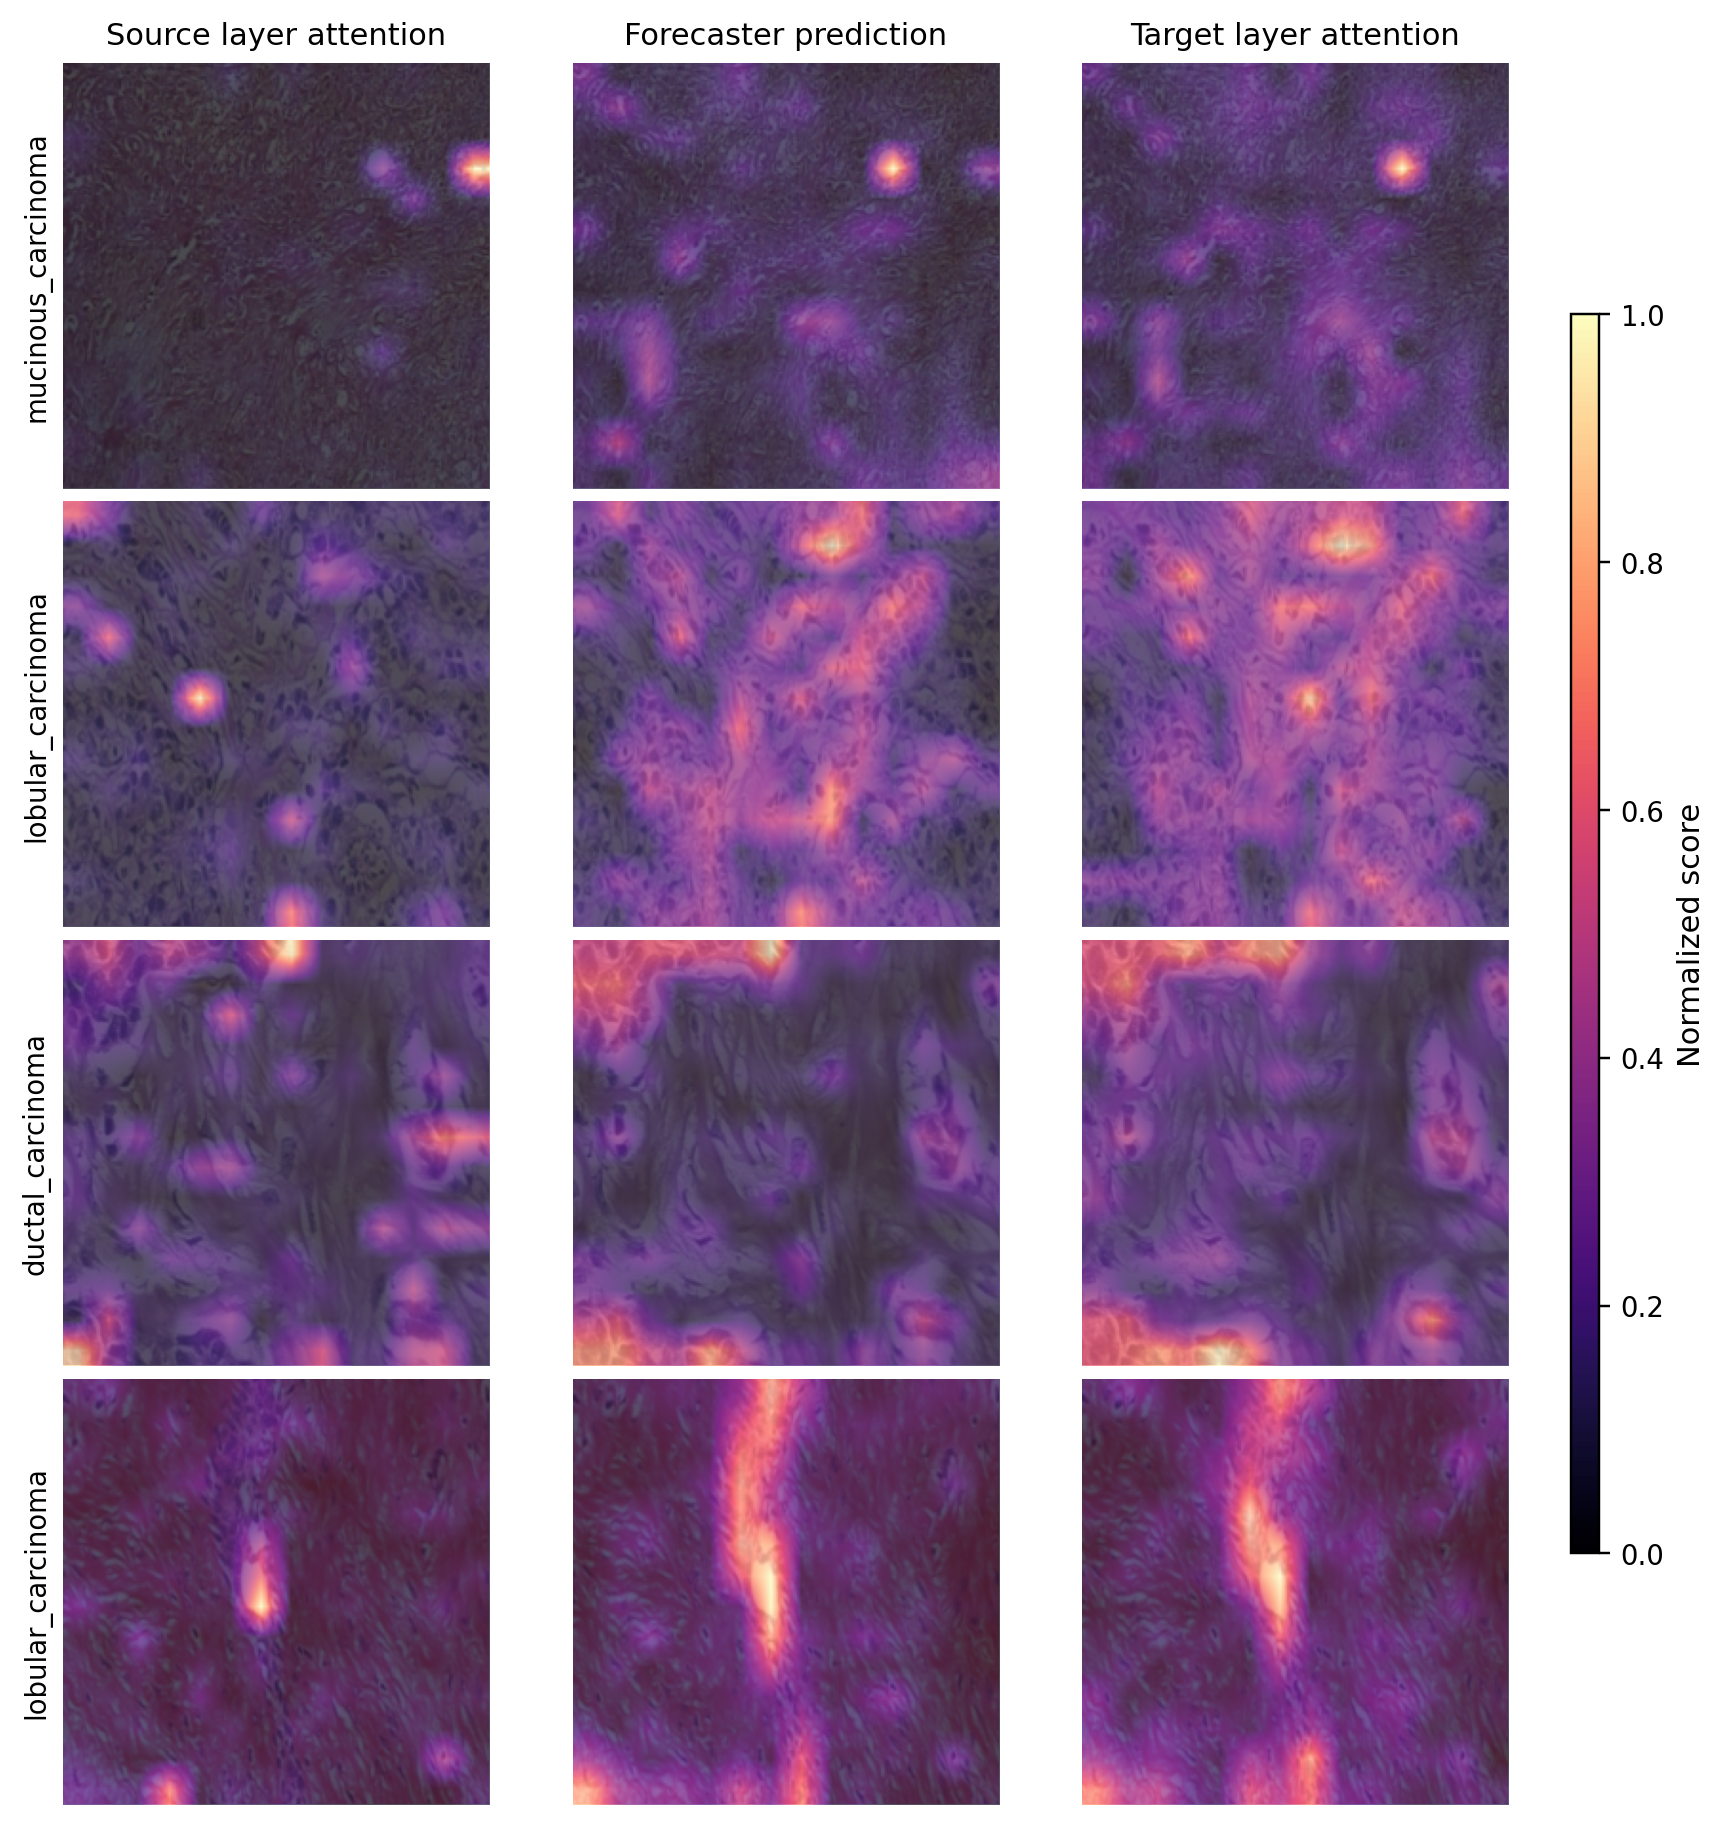

In [ ]:
CMAP = "magma"  # al posto di "magma"
ALPHA = 0.7    # leggermente più alta per compensare il minor contrasto percepito

# Orientamento verticale: righe = immagini, colonne = tipo mappa
fig = plt.figure(figsize=(2.6 * 3 + 0.8, 2.2 * N_IMAGES), dpi=220)
gs = gridspec.GridSpec(
    N_IMAGES,
    3,
    hspace=0.03,
    wspace=0.03,
    left=0.10,
    right=0.90,
    top=0.95,
    bottom=0.05,
)

COL_LABELS = [
    f"Source layer attention",
    "Forecaster prediction",
    f"Target layer attention",
]

for row in range(N_IMAGES):
    img_np = unnorm(sample_imgs[row])
    maps = [to_map(attn_x[row]), to_map(attn_pred[row]), to_map(attn_y[row])]

    for col, m in enumerate(maps):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img_np)
        ax.imshow(m, cmap=CMAP, alpha=ALPHA,
                  extent=[0, 224, 224, 0],
                  interpolation="bilinear", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        if row == 0:
            ax.set_title(COL_LABELS[col], fontsize=10, pad=6)
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[sample_labels[row]], fontsize=9, rotation=90, labelpad=4)

cbar_ax = fig.add_axes([0.915, 0.18, 0.015, 0.64])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=plt.Normalize(0, 1))
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Normalized score", fontsize=10)
cbar.ax.tick_params(labelsize=9)


out_base = CFG["results_dir"] / "attention_maps_comparison_article"
fig.savefig(str(out_base) + ".pdf", bbox_inches="tight")
fig.savefig(str(out_base) + ".png", dpi=450, bbox_inches="tight")
plt.show()



In [ ]:
def score_random(emb, attn):
    assert emb is not None, "emb non catturato dall'hook"
    B, N, D = emb.shape
    return torch.rand(B, N, device=emb.device)

def score_cls_attention(emb, attn):
    assert attn is not None, "attn non catturato dall'hook"
    return attn[:, :, 0, 1:].mean(1)

def make_score_forecaster(forecaster):
    def score_fn(emb, attn):
        assert emb is not None, "emb non catturato dall'hook"
        return forecaster(emb)
    return score_fn

In [ ]:
METHODS = [
    ("Random",
     score_random,
     classifier),

    ("CLS Attention",
     score_cls_attention,
     classifier),


    ("Forecaster + FT",
     make_score_forecaster(forecaster),
     classifier_ft_pruned),
]

METHOD_STYLES = {
    "Random"             : {"color": "#aaaaaa", "ls": "--", "marker": "x",  "lw": 1.5},
    "CLS Attention"      : {"color": "#4878cf", "ls": "--", "marker": "s",  "lw": 1.5},
    "Forecaster + FT"    : {"color": "#e63946", "ls": "-",  "marker": "o",  "lw": 2.5},
}

In [ ]:
results = []  # lista di dict

for method_name, score_fn, model in tqdm(METHODS, desc="Methods"):
    for keep_ratio in tqdm(CFG["keep_ratios"], desc=method_name, leave=False):
        all_preds, all_labels, all_scores = [], [], []

        for imgs, labels in test_loader:
            logits = forward_with_pruning(
                model, imgs, device,
                prune_layer = CFG["prune_layer"],
                keep_ratio  = keep_ratio,
                score_fn    = score_fn,
            )
            probs  = logits.softmax(-1).cpu()
            preds  = probs.argmax(-1)
            scores = probs.max(-1).values
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
            all_scores.extend(scores.numpy())

        metrics = compute_metrics(all_preds, all_labels, all_scores,
                                   CFG["far_threshold"])
        results.append({
            "method"      : method_name,
            "keep_ratio"  : keep_ratio,
            "keep_pct"    : int(keep_ratio * 100),
            "f1_macro"    : metrics["f1_macro"],
            "tar_at_far"  : metrics["tar_at_far"],
        })
        print(f"  {method_name:25s} keep={int(keep_ratio*100):3d}% "
              f"| F1={metrics['f1_macro']:.3f} "
              f"| TAR={metrics['tar_at_far']:.3f}")


Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Random:   0%|          | 0/8 [00:00<?, ?it/s]

  Random                    keep= 10% | F1=0.845 | TAR=0.040
  Random                    keep= 20% | F1=0.935 | TAR=0.030
  Random                    keep= 30% | F1=0.967 | TAR=0.042
  Random                    keep= 40% | F1=0.981 | TAR=0.022
  Random                    keep= 50% | F1=0.986 | TAR=0.016
  Random                    keep= 60% | F1=0.986 | TAR=0.034
  Random                    keep= 70% | F1=0.987 | TAR=0.037
  Random                    keep= 80% | F1=0.987 | TAR=0.018


CLS Attention:   0%|          | 0/8 [00:00<?, ?it/s]

  CLS Attention             keep= 10% | F1=0.794 | TAR=0.010
  CLS Attention             keep= 20% | F1=0.915 | TAR=0.008
  CLS Attention             keep= 30% | F1=0.953 | TAR=0.014
  CLS Attention             keep= 40% | F1=0.978 | TAR=0.075
  CLS Attention             keep= 50% | F1=0.984 | TAR=0.061
  CLS Attention             keep= 60% | F1=0.987 | TAR=0.033
  CLS Attention             keep= 70% | F1=0.987 | TAR=0.045
  CLS Attention             keep= 80% | F1=0.987 | TAR=0.055


Forecaster + FT:   0%|          | 0/8 [00:00<?, ?it/s]

  Forecaster + FT           keep= 10% | F1=0.970 | TAR=0.317
  Forecaster + FT           keep= 20% | F1=0.983 | TAR=0.623
  Forecaster + FT           keep= 30% | F1=0.986 | TAR=0.957
  Forecaster + FT           keep= 40% | F1=0.986 | TAR=0.865
  Forecaster + FT           keep= 50% | F1=0.987 | TAR=0.818
  Forecaster + FT           keep= 60% | F1=0.986 | TAR=0.754
  Forecaster + FT           keep= 70% | F1=0.987 | TAR=0.709
  Forecaster + FT           keep= 80% | F1=0.987 | TAR=0.715


In [ ]:
df = pd.DataFrame(results)
csv_path = CFG["results_dir"] / "pruning_comparison.csv"
df.to_csv(csv_path, index=False)
print(f"Risultati salvati in {csv_path}")
print(df.to_string(index=False))

Risultati salvati in results/BREAKHIS/pruning_comparison.csv
         method  keep_ratio  keep_pct  f1_macro  tar_at_far
         Random         0.1        10  0.845076    0.040020
         Random         0.2        20  0.935233    0.029726
         Random         0.3        30  0.966980    0.042428
         Random         0.4        40  0.981214    0.021668
         Random         0.5        50  0.985522    0.015632
         Random         0.6        60  0.985953    0.033785
         Random         0.7        70  0.986994    0.037329
         Random         0.8        80  0.987080    0.017993
  CLS Attention         0.1        10  0.794088    0.010188
  CLS Attention         0.2        20  0.915245    0.007713
  CLS Attention         0.3        30  0.953460    0.014050
  CLS Attention         0.4        40  0.977900    0.074906
  CLS Attention         0.5        50  0.984345    0.061419
  CLS Attention         0.6        60  0.986663    0.033472
  CLS Attention         0.7        70  

In [ ]:
# pivot_f1  = df.pivot(index="method", columns="keep_pct", values="f1_macro")
# pivot_tar = df.pivot(index="method", columns="keep_pct", values="tar_at_far")

# def to_latex_table(pivot, metric_name, dataset_name):
#     cols = pivot.columns.tolist()
#     header = " & ".join([f"{c}\\%" for c in cols])
#     lines  = [
#         f"\\begin{{table}}[h]",
#         f"\\caption{{{metric_name} — {dataset_name}}}",
#         f"\\begin{{tabular}}{{l{'c'*len(cols)}}}",
#         f"\\toprule",
#         f"Method & {header} \\\\",
#         f"\\midrule",
#     ]
#     for method, row in pivot.iterrows():
#         best_col = row.idxmax()
#         vals = []
#         for col in cols:
#             v = row[col]
#             if col == best_col:
#                 vals.append(f"\\textbf{{{v:.3f}}}")
#             else:
#                 vals.append(f"{v:.3f}")
#         lines.append(f"{method} & {' & '.join(vals)} \\\\")
#     lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
#     return "\n".join(lines)

# latex_f1  = to_latex_table(pivot_f1,  "F1 Macro",  DATASET_NAME)
# latex_tar = to_latex_table(pivot_tar, "TAR@FAR",   DATASET_NAME)

# latex_path_f1  = CFG["results_dir"] / "table_f1.tex"
# latex_path_tar = CFG["results_dir"] / "table_tar.tex"
# latex_path_f1.write_text(latex_f1)
# latex_path_tar.write_text(latex_tar)
# print(f"Tabelle LaTeX salvate in {CFG['results_dir']}")
# print("\n── F1 Macro ──")
# print(latex_f1)

In [11]:
# === Confronto diretto a 3 metodi: No Pruning vs FT+Pruning vs CropR ===
import time
from functools import partial

from src.vision_transformer_copr import VisionTransformer as CroprVisionTransformer

CFG.setdefault(
    "no_pruning_ckpt",
    Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}/uni_finetuned/best_model.pt"),
)
CFG.setdefault(
    "ft_pruned_ckpt",
    Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}/pruned_finetuned/best_prune_layer2_keep10.pt"),
)
CFG.setdefault(
    "cropr_ckpt",
    Path(f"/data/checkpoints-Attention-Pruning/{DATASET_NAME}/uni_cropr/best_model.pt"),
)


class UNICroprVisionTransformer(CroprVisionTransformer):
    def __init__(self, cropr_cfg, init_values: float = 1e-5, **kwargs):
        super().__init__(cropr_cfg, **kwargs)
        dpr = [x.item() for x in torch.linspace(0, kwargs["drop_path_rate"], len(self.blocks))]
        if cropr_cfg["use_cropr"]:
            dpr[-1] = 0.0
        for blk_idx in range(len(self.blocks)):
            self.blocks[blk_idx] = timm.models.vision_transformer.Block(
                dim=self.embed_dim,
                num_heads=kwargs["num_heads"],
                qkv_bias=True,
                init_values=init_values,
                drop_path=dpr[blk_idx],
                norm_layer=partial(nn.LayerNorm, eps=1e-6),
            )


def build_cropr_model(n_classes):
    cropr_cfg = {
        "use_cropr": True,
        "pruning_rate": 8,
        "llf": False,
        "num_queries": 1,
        "num_heads": 1,
        "pre_attn_norm": False,
        "q_proj": False,
        "k_proj": False,
        "v_proj": False,
        "mlp": True,
        "mlp_ratio": 4.0,
        "training": True,
    }
    model_kwargs = dict(
        num_classes=N_CLASSES,
        img_size=CFG["img_size"],
        patch_size=16,
        embed_dim=1024,
        depth=24,
        num_heads=16,
        mlp_ratio=4.0,
        drop_path_rate=0.2,
        global_pool="avg",
        class_token=True,
    )
    return UNICroprVisionTransformer(cropr_cfg, init_values=1e-5, **model_kwargs)


class UNILoRAWithForecasterPruning(nn.Module):
    """Modello FT con pruning al layer indicato usando forecaster."""

    def __init__(self, n_classes, forecaster, prune_layer=2, keep_ratio=0.1, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True, init_values=1e-5, dynamic_img_size=True
        )
        lora_config = LoraConfig(
            r=8,
            lora_alpha=32,
            target_modules=["qkv", "proj", "fc1", "fc2"],
            lora_dropout=0.1,
            bias="none",
        )
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes)
        )
        self.forecaster = forecaster
        self.prune_layer = prune_layer
        self.keep_ratio = keep_ratio

    def _make_block_hook(self):
        def make_block_hook(idx):
            orig_fwd = self.backbone.model.blocks[idx].forward
            training = self.training
            forecaster = self.forecaster
            keep_ratio = self.keep_ratio

            def block_fwd(x):
                x = orig_fwd(x)
                B, N, _ = x.shape
                patch_emb = x[:, 1:]
                with torch.no_grad():
                    scores = forecaster(patch_emb)
                k_keep = max(1, int((N - 1) * keep_ratio))
                topk_vals = scores.topk(k_keep, dim=-1).values
                threshold = topk_vals[:, -1:]
                soft_mask = torch.sigmoid((scores - threshold) / 0.05)
                hard_mask = (scores >= threshold).float()
                st_mask = hard_mask - soft_mask.detach() + soft_mask

                cls_tok = x[:, :1, :]
                patches = x[:, 1:, :]
                topk_idx = scores.topk(k_keep, dim=-1).indices
                if training:
                    masked_patches = patches * st_mask.unsqueeze(-1)
                    kept = torch.stack([masked_patches[b][topk_idx[b]] for b in range(B)])
                else:
                    kept = torch.stack([patches[b][topk_idx[b]] for b in range(B)])
                return torch.cat([cls_tok, kept], dim=1)

            return block_fwd

        return make_block_hook

    def forward(self, x):
        make_block_hook = self._make_block_hook()
        orig_fwd = self.backbone.model.blocks[self.prune_layer].forward
        self.backbone.model.blocks[self.prune_layer].forward = make_block_hook(self.prune_layer)
        out = self.head(self.backbone(x))
        self.backbone.model.blocks[self.prune_layer].forward = orig_fwd
        return out


def load_model_state(model, ckpt_path, strict=False):
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    missing, unexpected = model.load_state_dict(state, strict=strict)
    if missing:
        print(f"[WARN] Missing keys ({ckpt_path}): {len(missing)}")
    if unexpected:
        print(f"[WARN] Unexpected keys ({ckpt_path}): {len(unexpected)}")


# 1) No pruning
classifier_no_pruning = UNILoRAClassifier(N_CLASSES).to(device)
load_model_state(classifier_no_pruning, CFG["no_pruning_ckpt"], strict=False)
classifier_no_pruning.eval()
for p in classifier_no_pruning.parameters():
    p.requires_grad_(False)

# 2) FT + pruning (checkpoint pruned_finetuned)
forecaster_ft = AttentionForecaster().to(device)
load_model_state(forecaster_ft, CFG["forecaster_ckpt"], strict=True)
forecaster_ft.eval()
for p in forecaster_ft.parameters():
    p.requires_grad_(False)

classifier_ft = UNILoRAWithForecasterPruning(
    N_CLASSES,
    forecaster=forecaster_ft,
    prune_layer=CFG.get("prune_layer", 2),
    keep_ratio=0.1,
).to(device)
load_model_state(classifier_ft, CFG["ft_pruned_ckpt"], strict=False)
classifier_ft.eval()
for p in classifier_ft.parameters():
    p.requires_grad_(False)

# 3) CropR
classifier_cropr = build_cropr_model(N_CLASSES).to(device)
load_model_state(classifier_cropr, CFG["cropr_ckpt"], strict=False)
classifier_cropr.eval()
for p in classifier_cropr.parameters():
    p.requires_grad_(False)

print("Tre modelli caricati per confronto diretto")


Cropr schedule (tokens remaining): [188, 180, 172, 164, 156, 148, 140, 132, 124, 116, 108, 100, 92, 84, 76, 68, 60, 52, 44, 36, 28, 20, 12]
Tre modelli caricati per confronto diretto


In [12]:
print("no_pruning_ckpt:", CFG["no_pruning_ckpt"])
print("ft_ckpt:", CFG["classifier_ckpt"])


no_pruning_ckpt: /data/checkpoints-Attention-Pruning/BREAKHIS/uni_finetuned/best_model.pt
ft_ckpt: /data/checkpoints-Attention-Pruning/BREAKHIS/uni_finetuned/best_model.pt


In [ ]:
@torch.no_grad()
def run_plain_inference(model, loader):
    all_preds, all_labels, all_scores = [], [], []
    model.eval()
    autocast_on = (device.type == "cuda")

    for imgs, labels in tqdm(loader, leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=autocast_on):
            logits = model(imgs)
        probs = logits.float().softmax(-1).cpu()
        preds = probs.argmax(-1)
        scores = probs.max(-1).values

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_scores.extend(scores.numpy())

    return all_preds, all_labels, all_scores


@torch.no_grad()
def compute_ms_per_image(model, loader, n_warmup=10):
    model.eval()
    autocast_on = (device.type == "cuda")

    for i, (imgs, _) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=autocast_on):
            _ = model(imgs)
        if i >= n_warmup:
            break

    if device.type == "cuda":
        torch.cuda.synchronize()

    t0, n_imgs = time.perf_counter(), 0
    for imgs, _ in tqdm(loader, leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=autocast_on):
            _ = model(imgs)
        if device.type == "cuda":
            torch.cuda.synchronize()
        n_imgs += len(imgs)

    return (time.perf_counter() - t0) / n_imgs * 1000


def compute_gflops_per_image(model, loader):
    try:
        from fvcore.nn import FlopCountAnalysis
    except Exception:
        return None

    model.eval()
    sample = next(iter(loader))[0][:1].to(device)
    autocast_on = (device.type == "cuda")
    try:
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=autocast_on):
            fa = FlopCountAnalysis(model, sample)
        fa.unsupported_ops_warnings(False)
        fa.uncalled_modules_warnings(False)
        return fa.total() / 1e9
    except Exception as e:
        print(f"[WARN] GFLOPs non calcolabili per {type(model).__name__}: {e}")
        return None


THREE_METHODS = [
    ("Baseline (No Pruning)", classifier_no_pruning),
    ("FT + Attention Pruning", classifier_ft),
    ("CropR", classifier_cropr),
]

results_3methods = []
for method_name, model in THREE_METHODS:
    preds, labels, scores = run_plain_inference(model, test_loader)
    metrics = compute_metrics(preds, labels, scores, CFG["far_threshold"])
    acc = float((np.array(preds) == np.array(labels)).mean())
    ms_img = compute_ms_per_image(model, test_loader, n_warmup=10)
    gflops = compute_gflops_per_image(model, test_loader)

    results_3methods.append({
        "method": method_name,
        "accuracy": acc,
        "f1_macro": metrics["f1_macro"],
        "tar_at_far": metrics["tar_at_far"],
        "ms_per_image": ms_img,
        "gflops": gflops,
    })
    gflops_txt = "NA" if gflops is None else f"{gflops:.2f}"
    print(
        f"{method_name:24s} | ACC={acc:.4f} | F1={metrics['f1_macro']:.4f} "
        f"| TAR={metrics['tar_at_far']:.4f} | ms/img={ms_img:.2f} | GFLOPs={gflops_txt}"
    )


  0%|          | 0/6833 [00:00<?, ?it/s]

  0%|          | 0/6833 [00:00<?, ?it/s]

In [ ]:
1/387.8

0.0025786487880350697

In [ ]:
df_3methods = pd.DataFrame(results_3methods)
comparison_path = CFG["results_dir"] / "three_methods_comparison.csv"
df_3methods.to_csv(comparison_path, index=False)
print(f"Confronto 3 metodi salvato in: {comparison_path}")
display(df_3methods)

# Grafico sintetico: qualità + latenza + costo computazionale
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

plot_order = ["Baseline (No Pruning)", "FT + Attention Pruning", "CropR"]
plot_df = df_3methods.set_index("method").loc[plot_order]

plot_df[["f1_macro"]].plot(kind="bar", ax=axes[0], rot=15, color=["#5f0f40", "#9a031e", "#0f4c5c"])
axes[0].set_title("Prestazioni")
axes[0].set_ylabel("F1 macro")
axes[0].grid(axis="y", alpha=0.25)

plot_df[["ms_per_image"]].plot(kind="bar", ax=axes[1], rot=15, color=["#e76f51", "#2a9d8f", "#264653"])
axes[1].set_title("Velocità")
axes[1].set_ylabel("ms / immagine")
axes[1].grid(axis="y", alpha=0.25)

plot_df[["gflops"]].plot(kind="bar", ax=axes[2], rot=15, color=["#6a4c93", "#1982c4", "#8ac926"])
axes[2].set_title("Costo computazionale")
axes[2].set_ylabel("GFLOPs / immagine")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
# === Paper plot: progressivo pruning patch + attenzione corrispondente ===
import matplotlib.patches as mpatches

PAPER_KEEP_RATIOS = [0.9, 0.7, 0.5, 0.3, 0.1]
PATCH_GRID = 14
PATCH_SIZE = CFG["img_size"] // PATCH_GRID
TARGET_LAYER = 23


def _get_forecaster_for_viz():
    f = globals().get("forecaster", None)
    if f is None:
        f = globals().get("forecaster_ft", None)
    if f is None:
        if "AttentionForecaster" not in globals():
            raise RuntimeError("AttentionForecaster non definito.")
        f = AttentionForecaster().to(device)
        f.load_state_dict(torch.load(CFG["forecaster_ckpt"], map_location=device))
        f.eval()
        for p in f.parameters():
            p.requires_grad_(False)
    return f


def _pick_one_well_predicted_image(model, forecaster, loader, max_scan_batches=40):
    best = {"sim": -1.0, "img": None, "label": None, "pred": None, "target": None}

    scanned = 0
    for imgs, labels in loader:
        imgs_dev = imgs.to(device)
        _, pred_b, targ_b = collect_attention_maps(model, forecaster, imgs_dev, CFG["prune_layer"], TARGET_LAYER)

        pred_n = torch.nn.functional.normalize(pred_b.float(), p=2, dim=1)
        targ_n = torch.nn.functional.normalize(targ_b.float(), p=2, dim=1)
        sims = (pred_n * targ_n).sum(dim=1)

        b_idx = int(torch.argmax(sims).item())
        b_sim = float(sims[b_idx].item())

        if b_sim > best["sim"]:
            best["sim"] = b_sim
            best["img"] = imgs[b_idx].cpu()
            best["label"] = int(labels[b_idx].item())
            best["pred"] = pred_b[b_idx].cpu()
            best["target"] = targ_b[b_idx].cpu()

        scanned += 1
        if scanned >= max_scan_batches:
            break

    if best["img"] is None:
        raise RuntimeError("Nessuna immagine trovata per la visualizzazione.")
    return best


def _unnorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()


def _norm14(vec196):
    m = vec196.reshape(PATCH_GRID, PATCH_GRID).numpy()
    m = (m - m.min()) / (m.max() - m.min() + 1e-8)
    return m


def _topk_mask_from_scores(scores196, keep_ratio):
    k = max(1, int(round(scores196.numel() * keep_ratio)))
    idx = torch.topk(scores196, k=k, largest=True).indices
    mask = torch.zeros_like(scores196, dtype=torch.bool)
    mask[idx] = True
    return mask.reshape(PATCH_GRID, PATCH_GRID)


def _apply_black_squares(img_hwc, keep_mask_14):
    out = img_hwc.copy()
    for r in range(PATCH_GRID):
        for c in range(PATCH_GRID):
            if not bool(keep_mask_14[r, c]):
                y0, y1 = r * PATCH_SIZE, (r + 1) * PATCH_SIZE
                x0, x1 = c * PATCH_SIZE, (c + 1) * PATCH_SIZE
                out[y0:y1, x0:x1, :] = 0.0
    return out


viz_forecaster = _get_forecaster_for_viz()
best = _pick_one_well_predicted_image(classifier, viz_forecaster, test_loader)

img_np = _unnorm(best["img"])
pred_map = _norm14(best["pred"])

fig, axes = plt.subplots(2, len(PAPER_KEEP_RATIOS), figsize=(3.2 * len(PAPER_KEEP_RATIOS), 6.2), dpi=240)

for i, kr in enumerate(PAPER_KEEP_RATIOS):
    keep_mask = _topk_mask_from_scores(best["pred"], kr)

    # Riga 1: immagine con patch rimosse (quadrati neri)
    img_pruned = _apply_black_squares(img_np, keep_mask)
    ax_top = axes[0, i]
    ax_top.imshow(img_pruned)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_title(f"Keep {int(kr*100)}%", fontsize=10, fontweight="semibold")
    for spine in ax_top.spines.values():
        spine.set_visible(False)

    # Riga 2: attenzione corrispondente (stessa maschera)
    ax_bot = axes[1, i]
    ax_bot.imshow(img_pruned)

    attn_masked = pred_map.copy()
    attn_masked[~keep_mask.numpy()] = 0.0

    im = ax_bot.imshow(
        attn_masked,
        cmap="magma",
        alpha=0.62,
        extent=[0, CFG["img_size"], CFG["img_size"], 0],
        interpolation="bilinear",
        vmin=0,
        vmax=1,
    )
    ax_bot.set_xticks([])
    ax_bot.set_yticks([])
    for spine in ax_bot.spines.values():
        spine.set_visible(False)

axes[0, 0].set_ylabel("Pruned image", fontsize=10, fontweight="semibold")
axes[1, 0].set_ylabel("Attention map", fontsize=10, fontweight="semibold")

fig.suptitle(
    f"Progressive Patch Pruning and Corresponding Attention ({DATASET_NAME})",
    fontsize=13,
    fontweight="bold",
    y=0.98,
)

cbar_ax = fig.add_axes([0.92, 0.19, 0.015, 0.58])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Normalized attention", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout(rect=[0, 0, 0.91, 0.95])

out_base = CFG["results_dir"] / "paper_progressive_pruning_attention"
fig.savefig(str(out_base) + ".pdf", bbox_inches="tight")
fig.savefig(str(out_base) + ".png", dpi=400, bbox_inches="tight")
plt.show()


NameError: name 'classifier' is not defined